# CCT-20 Data Preparation Notebook (Project-Ready Version)

This notebook is adapted to the file layout currently in this project and is intended for team handoff.

Pipeline summary:

1. Load official CCT-20 split annotation files from `CCT20/annotations/`
2. Build an image-level table with one primary class label per image
3. Parse timestamp and create day/night labels
4. Apply cleaning (remove `empty`, remove rare classes, optional sequence dedup)
5. Save standardized CSV files for training/evaluation
6. Save mapping + processing metadata for reproducibility

Expected local folder structure:

```text
CCT20/
├── images/
│   ├── ... image files ...
├── annotations/
│   ├── train_annotations.json
│   ├── cis_val_annotations.json
│   ├── trans_val_annotations.json
│   ├── cis_test_annotations.json
│   └── trans_test_annotations.json
└── processed/
```

Notes:
- We treat `cis_val` + `trans_val` as one unified `val` split by default.
- We keep `cis_test` as `cis`, and `trans_test` as `trans`.
- Full notation/handoff documentation is also provided in `CCT20_DATA_NOTATION.md`.


## 1. Imports


In [28]:
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

try:
    import torchvision.transforms as T
except ImportError:
    T = None

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

## 2. Config

Adjust these paths/options to match your machine and experiment design.


In [29]:
# ======== EDIT THESE PATHS ========
ROOT = Path('CCT20')
IMAGES_DIR = ROOT / 'images'
ANNOTATIONS_DIR = ROOT / 'annotations'
PROCESSED_DIR = ROOT / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Official CCT-20 split annotation files
TRAIN_ANN_JSON = ANNOTATIONS_DIR / 'train_annotations.json'
CIS_VAL_ANN_JSON = ANNOTATIONS_DIR / 'cis_val_annotations.json'
TRANS_VAL_ANN_JSON = ANNOTATIONS_DIR / 'trans_val_annotations.json'
CIS_TEST_ANN_JSON = ANNOTATIONS_DIR / 'cis_test_annotations.json'
TRANS_TEST_ANN_JSON = ANNOTATIONS_DIR / 'trans_test_annotations.json'

# If True: merge cis_val + trans_val into one unified split named `val`
# If False: cis_val -> `val`, trans_val -> `trans`
MERGE_TRANS_VAL_INTO_VAL = True

# Data cleaning options
REMOVE_EMPTY = True         # remove images labeled as `empty`
MIN_TRAIN_IMAGES = 50       # remove classes with < this many train images
KEEP_ONE_FRAME_PER_SEQ = True
TOP_K_CLASSES = None        # e.g. 10 or 15; set None to skip
EXCLUDE_CLASSES = ['car']   # classes to drop entirely (applied to all splits)

# Day/night manual time ranges (24h clock, HH:MM)
# You can leave gaps between day and night; uncovered time will be labeled `unknown`.
# Example full coverage:
#   DAY_TIME_RANGES = [('07:00', '19:00')]
#   NIGHT_TIME_RANGES = [('19:00', '24:00'), ('00:00', '07:00')]
DAY_TIME_RANGES = [('07:00', '19:00')]
NIGHT_TIME_RANGES = [('19:00', '24:00'), ('00:00', '07:00')]

# If a timestamp falls into both day and night ranges, pick this label.
# Options: 'day', 'night', 'unknown'
OVERLAP_POLICY = 'unknown'

# If timestamp is valid but not covered by either day or night ranges
UNCOVERED_LABEL = 'unknown'

# Image settings for PyTorch Dataset
IMG_SIZE = 224


## 3. Helper functions


In [30]:
def load_json(path):
    path = Path(path)
    with open(path, 'r') as f:
        return json.load(f)


def parse_datetime_safe(x):
    if pd.isna(x) or x is None:
        return pd.NaT
    x = str(x)
    fmts = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H:%M:%S',
        '%Y-%m-%dT%H:%M:%S',
        '%Y-%m-%d %H:%M:%S.%f',
    ]
    for fmt in fmts:
        try:
            return pd.Timestamp(datetime.strptime(x, fmt))
        except Exception:
            pass
    try:
        return pd.to_datetime(x)
    except Exception:
        return pd.NaT


def parse_hhmm_to_minute(hhmm):
    """Convert HH:MM string to minute index in [0, 1440]."""
    if not isinstance(hhmm, str) or ':' not in hhmm:
        raise ValueError(f'Invalid time format: {hhmm}. Expected HH:MM')
    hh, mm = hhmm.split(':', 1)
    hh = int(hh)
    mm = int(mm)
    if hh == 24 and mm == 0:
        return 1440
    if not (0 <= hh <= 23 and 0 <= mm <= 59):
        raise ValueError(f'Invalid clock time: {hhmm}')
    return hh * 60 + mm


def normalize_time_ranges(ranges):
    """
    Normalize list of (start, end) HH:MM ranges to half-open minute intervals.
    Supports wrap-around ranges (e.g., 22:00 -> 02:00).
    Output intervals use [start, end), end can be 1440.
    """
    out = []
    for start_s, end_s in ranges:
        start_m = parse_hhmm_to_minute(start_s)
        end_m = parse_hhmm_to_minute(end_s)

        if start_m == end_m:
            # Empty interval by default (avoid accidental full-day assignment)
            continue

        if start_m < end_m:
            out.append((start_m, end_m))
        else:
            # wrap-around, split into two intervals
            out.append((start_m, 1440))
            out.append((0, end_m))

    return out


def minute_in_ranges(minute_of_day, intervals):
    return any(start <= minute_of_day < end for start, end in intervals)


def timestamp_to_daynight(ts, day_intervals, night_intervals, overlap_policy='unknown', uncovered_label='unknown'):
    if pd.isna(ts):
        return 'unknown'

    minute_of_day = int(ts.hour) * 60 + int(ts.minute)
    in_day = minute_in_ranges(minute_of_day, day_intervals)
    in_night = minute_in_ranges(minute_of_day, night_intervals)

    if in_day and not in_night:
        return 'day'
    if in_night and not in_day:
        return 'night'
    if in_day and in_night:
        if overlap_policy not in {'day', 'night', 'unknown'}:
            raise ValueError(f'Invalid OVERLAP_POLICY: {overlap_policy}')
        return overlap_policy

    return uncovered_label


def collapse_annotations_to_image_level(ann_df, cat_map):
    """
    Convert annotation-level rows to one primary class per image.

    Rule:
    1. Prefer non-empty categories over `empty`
    2. Prefer larger bbox area when available
    3. Fall back to first annotation after sorting
    """
    if ann_df.empty:
        return pd.DataFrame(columns=['image_id', 'category_id', 'category_name', 'num_annotations', 'num_unique_categories', 'has_multi_category'])

    tmp = ann_df.copy()
    tmp['category_name'] = tmp['category_id'].map(cat_map)

    if 'bbox' in tmp.columns:
        tmp['bbox_area'] = tmp['bbox'].apply(
            lambda b: float(b[2]) * float(b[3]) if isinstance(b, (list, tuple)) and len(b) >= 4 else np.nan
        )
    else:
        tmp['bbox_area'] = np.nan

    tmp['is_non_empty'] = (tmp['category_name'] != 'empty').astype(int)

    sorted_tmp = tmp.sort_values(
        by=['image_id', 'is_non_empty', 'bbox_area'],
        ascending=[True, False, False],
        na_position='last'
    )

    primary = sorted_tmp.groupby('image_id', as_index=False).first()[['image_id', 'category_id', 'category_name']]

    stats = tmp.groupby('image_id', as_index=False).agg(
        num_annotations=('id', 'count'),
        num_unique_categories=('category_name', 'nunique')
    )
    stats['has_multi_category'] = stats['num_unique_categories'] > 1

    out = primary.merge(stats, on='image_id', how='left')
    return out


def load_split_annotation(split_name, ann_path):
    ann = load_json(ann_path)

    categories = ann.get('categories', [])
    images = ann.get('images', [])
    annotations = ann.get('annotations', [])

    cat_df = pd.DataFrame(categories)
    img_df = pd.DataFrame(images)
    ann_df = pd.DataFrame(annotations)

    if img_df.empty:
        return pd.DataFrame()

    cat_map = dict(zip(cat_df['id'], cat_df['name'])) if not cat_df.empty else {}
    ann_grouped = collapse_annotations_to_image_level(ann_df, cat_map)

    df_split = img_df.rename(columns={'id': 'image_id'}).merge(ann_grouped, on='image_id', how='left')

    for col in ['datetime', 'date_captured', 'location', 'seq_id', 'seq_num_frames', 'frame_num']:
        if col not in df_split.columns:
            df_split[col] = np.nan

    df_split['split'] = split_name
    df_split['source_file'] = Path(ann_path).name
    df_split['category_name'] = df_split['category_name'].fillna('empty')
    df_split['is_empty'] = (df_split['category_name'] == 'empty').astype(int)

    return df_split


def choose_one_frame_per_seq(df, strategy='first'):
    df = df.copy()
    if 'seq_id' not in df.columns:
        return df
    if strategy == 'first':
        sort_cols = [c for c in ['split', 'seq_id', 'frame_num', 'datetime_parsed'] if c in df.columns]
        if sort_cols:
            df = df.sort_values(sort_cols)
        return df.groupby(['split', 'seq_id'], as_index=False).head(1).reset_index(drop=True)
    raise ValueError(f'Unknown strategy: {strategy}')


def summarize_df(df, name='df'):
    print(f'===== {name} =====')
    print('rows:', len(df))
    if 'split' in df.columns:
        print('\nsplit counts:')
        print(df['split'].value_counts(dropna=False))
    if 'category_name' in df.columns:
        print('\nclass counts (top 20):')
        print(df['category_name'].value_counts(dropna=False).head(20))
    if 'day_night' in df.columns:
        print('\nday/night counts:')
        print(df['day_night'].value_counts(dropna=False))
    if 'location' in df.columns:
        print('\n# locations:', df['location'].nunique())


## 4. Load split annotation files and build a unified image-level table

This version reads the official split JSON files directly from `CCT20/annotations/`.


In [31]:
split_sources = [
    ('train', TRAIN_ANN_JSON),
    ('val', CIS_VAL_ANN_JSON),
    ('val' if MERGE_TRANS_VAL_INTO_VAL else 'trans', TRANS_VAL_ANN_JSON),
    ('cis', CIS_TEST_ANN_JSON),
    ('trans', TRANS_TEST_ANN_JSON),
]

parts = []
for split_name, path in split_sources:
    path = Path(path)
    if not path.exists():
        print(f'[warn] missing file: {path}')
        continue
    part = load_split_annotation(split_name, path)
    print(f'loaded {split_name:<5} from {path.name}: {len(part)} rows')
    parts.append(part)

if len(parts) == 0:
    raise FileNotFoundError('No annotation files found. Please check config paths.')

df = pd.concat(parts, ignore_index=True)
print('all rows:', len(df))
print('columns:', sorted(df.columns.tolist()))


loaded train from train_annotations.json: 13553 rows
loaded val   from cis_val_annotations.json: 3484 rows
loaded val   from trans_val_annotations.json: 1725 rows
loaded cis   from cis_test_annotations.json: 15827 rows
loaded trans from trans_test_annotations.json: 23275 rows
all rows: 57864
columns: ['category_id', 'category_name', 'date_captured', 'datetime', 'file_name', 'frame_num', 'has_multi_category', 'height', 'image_id', 'is_empty', 'location', 'num_annotations', 'num_unique_categories', 'rights_holder', 'seq_id', 'seq_num_frames', 'source_file', 'split', 'width']


## 5. Quick sanity check of loaded table


In [32]:
summarize_df(df, 'raw_loaded')

df[['file_name', 'split', 'category_name', 'source_file', 'seq_id', 'frame_num']].head()


===== raw_loaded =====
rows: 57864

split counts:
split
trans    23275
cis      15827
train    13553
val       5209
Name: count, dtype: int64

class counts (top 20):
category_name
opossum     13688
raccoon      7841
rabbit       5545
coyote       5318
bobcat       4968
cat          4601
empty        4014
squirrel     3180
dog          2788
car          2613
bird         1403
skunk         857
rodent        809
deer          207
badger         24
fox             8
Name: count, dtype: int64

# locations: 20


,file_name,split,category_name,source_file,seq_id,frame_num
0,5a2176e7-23d2-11e8-a6a3-ec086b02610b.jpg,train,dog,train_annotations.json,6f011019-5567-11e8-a650-dca9047ef277,2
1,5a2177bf-23d2-11e8-a6a3-ec086b02610b.jpg,train,cat,train_annotations.json,6f003940-5567-11e8-afb4-dca9047ef277,3
2,59af966d-23d2-11e8-a6a3-ec086b02610b.jpg,train,bobcat,train_annotations.json,6f0be74a-5567-11e8-8662-dca9047ef277,3
3,59a30d59-23d2-11e8-a6a3-ec086b02610b.jpg,train,bird,train_annotations.json,70134747-5567-11e8-8313-dca9047ef277,1
4,59ffbb81-23d2-11e8-a6a3-ec086b02610b.jpg,train,cat,train_annotations.json,6f000b51-5567-11e8-9c1b-dca9047ef277,1


In [33]:
# Optional consistency checks
print('num rows:', len(df))
print('unique image_id:', df['image_id'].nunique())
print('rows with multiple categories in source annotations:', int(df.get('has_multi_category', pd.Series(dtype=bool)).fillna(False).sum()))


num rows: 57864
unique image_id: 57864
rows with multiple categories in source annotations: 78


## 6. Parse timestamp and create day/night label

CCT-20 files usually provide `date_captured`. Some variants use `datetime`.
We use `datetime` first, then fallback to `date_captured`.

Day/night is configured by manual time ranges:
- `DAY_TIME_RANGES = [(start, end), ...]`
- `NIGHT_TIME_RANGES = [(start, end), ...]`

The two sets do not need to cover 24 hours.
Any uncovered timestamp will be labeled by `UNCOVERED_LABEL` (default `unknown`).


In [34]:
df['datetime_raw'] = df['datetime'].where(df['datetime'].notna(), df['date_captured'])
df['datetime_parsed'] = df['datetime_raw'].apply(parse_datetime_safe)
df['hour'] = df['datetime_parsed'].dt.hour

day_intervals = normalize_time_ranges(DAY_TIME_RANGES)
night_intervals = normalize_time_ranges(NIGHT_TIME_RANGES)

print('day_intervals(minute):', day_intervals)
print('night_intervals(minute):', night_intervals)

df['day_night'] = df['datetime_parsed'].apply(
    lambda ts: timestamp_to_daynight(
        ts,
        day_intervals,
        night_intervals,
        overlap_policy=OVERLAP_POLICY,
        uncovered_label=UNCOVERED_LABEL,
    )
)

df[['file_name', 'datetime', 'date_captured', 'datetime_raw', 'datetime_parsed', 'hour', 'day_night']].head()


day_intervals(minute): [(420, 1140)]
night_intervals(minute): [(1140, 1440), (0, 420)]


,file_name,datetime,date_captured,datetime_raw,datetime_parsed,hour,day_night
0,5a2176e7-23d2-11e8-a6a3-ec086b02610b.jpg,NaN,2011-11-29 17:28:26,2011-11-29 17:28:26,2011-11-29 17:28:26,17,day
1,5a2177bf-23d2-11e8-a6a3-ec086b02610b.jpg,NaN,2011-10-06 11:49:18,2011-10-06 11:49:18,2011-10-06 11:49:18,11,day
2,59af966d-23d2-11e8-a6a3-ec086b02610b.jpg,NaN,2011-12-15 09:50:03,2011-12-15 09:50:03,2011-12-15 09:50:03,9,day
3,59a30d59-23d2-11e8-a6a3-ec086b02610b.jpg,NaN,2013-01-22 09:25:16,2013-01-22 09:25:16,2013-01-22 09:25:16,9,day
4,59ffbb81-23d2-11e8-a6a3-ec086b02610b.jpg,NaN,2011-09-18 23:14:54,2011-09-18 23:14:54,2011-09-18 23:14:54,23,night


## 7. Split sanity check

Splits are already assigned while loading files.


In [35]:
valid_splits = {'train', 'val', 'cis', 'trans'}
observed_splits = set(df['split'].dropna().unique().tolist())
print('observed_splits =', observed_splits)
print('unexpected_splits =', observed_splits - valid_splits)

summarize_df(df, 'raw_with_split')


observed_splits = {'val', 'cis', 'trans', 'train'}
unexpected_splits = set()
===== raw_with_split =====
rows: 57864

split counts:
split
trans    23275
cis      15827
train    13553
val       5209
Name: count, dtype: int64

class counts (top 20):
category_name
opossum     13688
raccoon      7841
rabbit       5545
coyote       5318
bobcat       4968
cat          4601
empty        4014
squirrel     3180
dog          2788
car          2613
bird         1403
skunk         857
rodent        809
deer          207
badger         24
fox             8
Name: count, dtype: int64

day/night counts:
day_night
night    33171
day      24693
Name: count, dtype: int64

# locations: 20


## 8. Basic cleaning

This step optionally:
- removes `empty`
- keeps only classes that have enough training samples
- optionally keeps only top-K train classes
- hard-excludes classes listed in `EXCLUDE_CLASSES`

Important:
- class filtering thresholds are computed **only on `train` split**
- then applied to all splits for a consistent label space


In [36]:
clean_df = df.copy()

if REMOVE_EMPTY:
    clean_df = clean_df[clean_df['category_name'] != 'empty'].copy()

if EXCLUDE_CLASSES:
    clean_df = clean_df[~clean_df['category_name'].isin(EXCLUDE_CLASSES)].copy()

train_df = clean_df[clean_df['split'] == 'train'].copy()
train_counts = train_df['category_name'].value_counts()

keep_classes = train_counts[train_counts >= MIN_TRAIN_IMAGES].index.tolist()

if TOP_K_CLASSES is not None:
    keep_classes = train_counts.loc[keep_classes].head(TOP_K_CLASSES).index.tolist()

clean_df = clean_df[clean_df['category_name'].isin(keep_classes)].copy()

summarize_df(clean_df, 'after_class_filter')
print('\nkept classes:', sorted(clean_df['category_name'].unique().tolist()))


===== after_class_filter =====
rows: 50998

split counts:
split
trans    20369
cis      13688
train    12833
val       4108
Name: count, dtype: int64

class counts (top 20):
category_name
opossum     13688
raccoon      7841
rabbit       5545
coyote       5318
bobcat       4968
cat          4601
squirrel     3180
dog          2788
bird         1403
skunk         857
rodent        809
Name: count, dtype: int64

day/night counts:
day_night
night    31257
day      19741
Name: count, dtype: int64

# locations: 20

kept classes: ['bird', 'bobcat', 'cat', 'coyote', 'dog', 'opossum', 'rabbit', 'raccoon', 'rodent', 'skunk', 'squirrel']


## 9. Optional sequence deduplication

Camera trap bursts often contain many near-duplicate frames in the same sequence.
A simple baseline is to keep only one frame per `seq_id`.


In [37]:
if KEEP_ONE_FRAME_PER_SEQ:
    dedup_df = choose_one_frame_per_seq(clean_df, strategy='first')
else:
    dedup_df = clean_df.copy()

summarize_df(dedup_df, 'after_seq_dedup')

===== after_seq_dedup =====
rows: 18581

split counts:
split
trans    7145
cis      5091
train    4816
val      1529
Name: count, dtype: int64

class counts (top 20):
category_name
opossum     4508
coyote      2628
raccoon     2621
rabbit      1938
bobcat      1897
cat         1518
dog         1153
squirrel    1091
bird         531
skunk        414
rodent       282
Name: count, dtype: int64

day/night counts:
day_night
night    11387
day       7194
Name: count, dtype: int64

# locations: 20


## 10. Create numeric labels


In [38]:
class_names = sorted(dedup_df['category_name'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

dedup_df['label'] = dedup_df['category_name'].map(class_to_idx)

print('num_classes =', len(class_names))
print(class_to_idx)
dedup_df[['file_name', 'category_name', 'label']].head()

num_classes = 11
{'bird': 0, 'bobcat': 1, 'cat': 2, 'coyote': 3, 'dog': 4, 'opossum': 5, 'rabbit': 6, 'raccoon': 7, 'rodent': 8, 'skunk': 9, 'squirrel': 10}


,file_name,category_name,label
0,5a2c847d-23d2-11e8-a6a3-ec086b02610b.jpg,dog,4
1,59a94aea-23d2-11e8-a6a3-ec086b02610b.jpg,dog,4
2,597cd6c3-23d2-11e8-a6a3-ec086b02610b.jpg,dog,4
3,59c1784d-23d2-11e8-a6a3-ec086b02610b.jpg,opossum,5
4,5995af15-23d2-11e8-a6a3-ec086b02610b.jpg,opossum,5


## 11. Save processed CSV, label mapping, and processing metadata


In [39]:
full_csv = PROCESSED_DIR / 'cct20_clean_all.csv'
train_csv = PROCESSED_DIR / 'cct20_train.csv'
val_csv = PROCESSED_DIR / 'cct20_val.csv'
cis_csv = PROCESSED_DIR / 'cct20_cis.csv'
trans_csv = PROCESSED_DIR / 'cct20_trans.csv'
mapping_json = PROCESSED_DIR / 'label_mapping.json'
meta_json = PROCESSED_DIR / 'data_processing_spec.json'

dedup_df.to_csv(full_csv, index=False)
dedup_df[dedup_df['split'] == 'train'].to_csv(train_csv, index=False)
dedup_df[dedup_df['split'] == 'val'].to_csv(val_csv, index=False)
dedup_df[dedup_df['split'] == 'cis'].to_csv(cis_csv, index=False)
dedup_df[dedup_df['split'] == 'trans'].to_csv(trans_csv, index=False)

with open(mapping_json, 'w') as f:
    json.dump({
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
    }, f, indent=2)

processing_meta = {
    'source_files': {
        'train': str(TRAIN_ANN_JSON),
        'cis_val': str(CIS_VAL_ANN_JSON),
        'trans_val': str(TRANS_VAL_ANN_JSON),
        'cis_test': str(CIS_TEST_ANN_JSON),
        'trans_test': str(TRANS_TEST_ANN_JSON),
    },
    'merge_trans_val_into_val': MERGE_TRANS_VAL_INTO_VAL,
    'cleaning_options': {
        'REMOVE_EMPTY': REMOVE_EMPTY,
        'MIN_TRAIN_IMAGES': MIN_TRAIN_IMAGES,
        'KEEP_ONE_FRAME_PER_SEQ': KEEP_ONE_FRAME_PER_SEQ,
        'TOP_K_CLASSES': TOP_K_CLASSES,
        'EXCLUDE_CLASSES': EXCLUDE_CLASSES,
        'DAY_TIME_RANGES': DAY_TIME_RANGES,
        'NIGHT_TIME_RANGES': NIGHT_TIME_RANGES,
        'OVERLAP_POLICY': OVERLAP_POLICY,
        'UNCOVERED_LABEL': UNCOVERED_LABEL,
    },
    'output_files': {
        'full_csv': str(full_csv),
        'train_csv': str(train_csv),
        'val_csv': str(val_csv),
        'cis_csv': str(cis_csv),
        'trans_csv': str(trans_csv),
        'mapping_json': str(mapping_json),
    },
    'column_semantics_hint': {
        'datetime_raw': 'Chosen timestamp source: datetime if available else date_captured',
        'day_night': 'Derived from manual DAY_TIME_RANGES/NIGHT_TIME_RANGES with OVERLAP_POLICY and UNCOVERED_LABEL',
        'has_multi_category': 'True if one image has >1 category in source annotations',
    }
}

with open(meta_json, 'w') as f:
    json.dump(processing_meta, f, indent=2)

print('saved:', full_csv)
print('saved:', mapping_json)
print('saved:', meta_json)


saved: CCT20/processed/cct20_clean_all.csv
saved: CCT20/processed/label_mapping.json
saved: CCT20/processed/data_processing_spec.json


## 12. Optional analysis: class counts by split


In [40]:
pd.crosstab(dedup_df['category_name'], dedup_df['split']).sort_index()

split,cis,train,trans,val
category_name,,,,
bird,198,186,80,67
bobcat,384,324,864,325
cat,545,430,453,90
coyote,762,760,965,141
dog,340,320,406,87
opossum,1510,914,1763,321
rabbit,589,855,281,213
raccoon,349,345,1825,102
rodent,80,128,21,53


## 13. Optional analysis: day/night by split


In [41]:
pd.crosstab(dedup_df['day_night'], dedup_df['split'])

split,cis,train,trans,val
day_night,,,,
day,1948,2112,2443,691
night,3143,2704,4702,838


## 14. Build custom day/night experiment splits

This is useful for your proposal question:
- train on day, test on night
- train on night, test on day

Below we create example CSVs inside the official `train` split.


In [42]:
official_train = dedup_df[dedup_df['split'] == 'train'].copy()

train_day = official_train[official_train['day_night'] == 'day'].copy()
train_night = official_train[official_train['day_night'] == 'night'].copy()

train_day.to_csv(PROCESSED_DIR / 'cct20_train_day.csv', index=False)
train_night.to_csv(PROCESSED_DIR / 'cct20_train_night.csv', index=False)

print('train_day:', len(train_day))
print('train_night:', len(train_night))

train_day: 2112
train_night: 2704


## 15. Output file notes + per-dataset class statistics

Output file definitions:

- `cct20_clean_all.csv`：清洗后全量
- `cct20_train.csv`：训练集
- `cct20_val.csv`：验证集
- `cct20_cis.csv`：同地点测试域
- `cct20_trans.csv`：跨地点测试域
- `cct20_train_day.csv`：训练集中的白天子集（时间区间由 DAY_TIME_RANGES 定义）
- `cct20_train_night.csv`：训练集中的夜间子集（时间区间由 NIGHT_TIME_RANGES 定义）
- `label_mapping.json`：类别到数字标签映射
- `data_processing_spec.json`：本次清洗配置与输入输出元信息


In [67]:
output_desc = {
    'cct20_clean_all.csv': '清洗后全量',
    'cct20_train.csv': '训练集',
    'cct20_val.csv': '验证集',
    'cct20_cis.csv': '同地点测试域',
    'cct20_trans.csv': '跨地点测试域',
    'cct20_train_day.csv': '训练集中的白天子集（时间区间由 DAY_TIME_RANGES 定义）',
    'cct20_train_night.csv': '训练集中的夜间子集（时间区间由 NIGHT_TIME_RANGES 定义）',
    'label_mapping.json': '类别到数字标签映射',
    'data_processing_spec.json': '本次清洗配置与输入输出元信息',
}

print('===== Output file notes =====')
for k, v in output_desc.items():
    print(f'- {k}: {v}')

# Build dataset views directly from dedup_df so this cell works even before CSV reload.
dataset_views = {
    'cct20_clean_all.csv': dedup_df,
    'cct20_train.csv': dedup_df[dedup_df['split'] == 'train'],
    'cct20_val.csv': dedup_df[dedup_df['split'] == 'val'],
    'cct20_cis.csv': dedup_df[dedup_df['split'] == 'cis'],
    'cct20_trans.csv': dedup_df[dedup_df['split'] == 'trans'],
    'cct20_train_day.csv': dedup_df[(dedup_df['split'] == 'train') & (dedup_df['day_night'] == 'day')],
    'cct20_train_night.csv': dedup_df[(dedup_df['split'] == 'train') & (dedup_df['day_night'] == 'night')],
}

class_count_tables = {}
for dataset_name, df_ in dataset_views.items():
    counts = df_['category_name'].value_counts().sort_index()
    class_count_tables[dataset_name] = counts

    print(f"\n===== {dataset_name} ({output_desc[dataset_name]}) =====")
    print('rows:', len(df_))
    print('num_classes:', counts.shape[0])
    print(counts)

# Wide table: rows=class, cols=dataset
class_count_summary = pd.DataFrame(class_count_tables).fillna(0).astype(int).sort_index()
print('\n===== Class count summary (rows=class, cols=dataset) =====')
class_count_summary


===== Output file notes =====
- cct20_clean_all.csv: 清洗后全量
- cct20_train.csv: 训练集
- cct20_val.csv: 验证集
- cct20_cis.csv: 同地点测试域
- cct20_trans.csv: 跨地点测试域
- cct20_train_day.csv: 训练集中的白天子集（时间区间由 DAY_TIME_RANGES 定义）
- cct20_train_night.csv: 训练集中的夜间子集（时间区间由 NIGHT_TIME_RANGES 定义）
- label_mapping.json: 类别到数字标签映射
- data_processing_spec.json: 本次清洗配置与输入输出元信息

===== cct20_clean_all.csv (清洗后全量) =====
rows: 18581
num_classes: 11
category_name
bird         531
bobcat      1897
cat         1518
coyote      2628
dog         1153
opossum     4508
rabbit      1938
raccoon     2621
rodent       282
skunk        414
squirrel    1091
Name: count, dtype: int64

===== cct20_train.csv (训练集) =====
rows: 4816
num_classes: 11
category_name
bird        186
bobcat      324
cat         430
coyote      760
dog         320
opossum     914
rabbit      855
raccoon     345
rodent      128
skunk       122
squirrel    432
Name: count, dtype: int64

===== cct20_val.csv (验证集) =====
rows: 1529
num_classes: 11
category_name
b

,cct20_clean_all.csv,cct20_train.csv,cct20_val.csv,cct20_cis.csv,cct20_trans.csv,cct20_train_day.csv,cct20_train_night.csv
category_name,,,,,,,
bird,531,186,67,198,80,168,18
bobcat,1897,324,325,384,864,109,215
cat,1518,430,90,545,453,212,218
coyote,2628,760,141,762,965,259,501
dog,1153,320,87,340,406,262,58
opossum,4508,914,321,1510,1763,77,837
rabbit,1938,855,213,589,281,519,336
raccoon,2621,345,102,349,1825,35,310
rodent,282,128,53,80,21,16,112


## 16. PyTorch Dataset

This class reads from the cleaned CSV we created above.


In [43]:
class CCT20ClassificationDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.images_dir = Path(images_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.images_dir / row['file_name']

        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform is not None:
            image = self.transform(image)

        sample = {
            'image': image,
            'label': label,
            'file_name': row['file_name'],
            'location': row.get('location', None),
            'day_night': row.get('day_night', None),
            'category_name': row.get('category_name', None),
            'seq_id': row.get('seq_id', None),
        }
        return sample

## 17. Transforms


In [44]:
if T is None:
    print('torchvision is not installed.')
else:
    train_transform = T.Compose([
        T.Resize((256, 256)),
        T.RandomResizedCrop(IMG_SIZE),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    eval_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    print('Transforms are ready.')

Transforms are ready.


## 18. Build dataloaders


In [45]:
if T is not None:
    train_dataset = CCT20ClassificationDataset(train_csv, IMAGES_DIR, transform=train_transform)
    cis_dataset = CCT20ClassificationDataset(cis_csv, IMAGES_DIR, transform=eval_transform)
    trans_dataset = CCT20ClassificationDataset(trans_csv, IMAGES_DIR, transform=eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    cis_loader = DataLoader(cis_dataset, batch_size=32, shuffle=False, num_workers=4)
    trans_loader = DataLoader(trans_dataset, batch_size=32, shuffle=False, num_workers=4)

    print('train:', len(train_dataset))
    print('cis:', len(cis_dataset))
    print('trans:', len(trans_dataset))

train: 4816
cis: 5091
trans: 7145


## 19. Visual sanity check


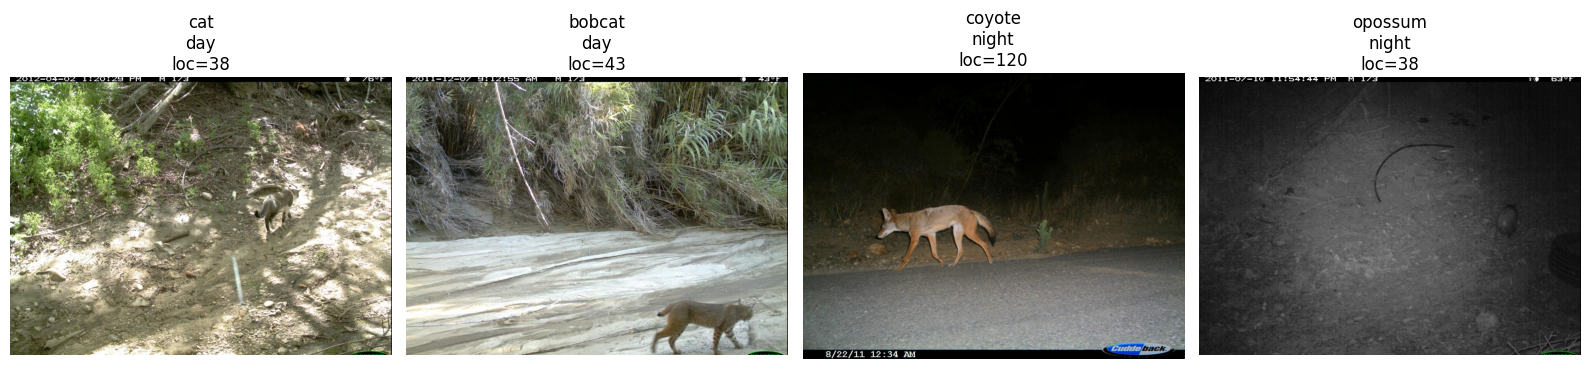

In [46]:
import matplotlib.pyplot as plt

def show_raw_examples(csv_path, images_dir, n=6):
    df_ = pd.read_csv(csv_path).sample(min(n, len(pd.read_csv(csv_path))), random_state=0)
    fig, axes = plt.subplots(1, len(df_), figsize=(4 * len(df_), 4))
    if len(df_) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, df_.iterrows()):
        img = Image.open(Path(images_dir) / row['file_name']).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"{row['category_name']}\n{row['day_night']}\nloc={row.get('location', 'NA')}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_raw_examples(train_csv, IMAGES_DIR, n=4)

## 20. Notes for your project design

Recommended baseline experiments:

1. **Cross-location generalization**
   - train on `train`
   - evaluate on `cis` and `trans`
   - compare the performance gap

2. **Cross-time generalization**
   - train on `train_day`, test on night subset
   - train on `train_night`, test on day subset
   - compare with mixed day+night training

3. **Environmental/domain shift analysis**
   - compare full image vs crop-based image if bbox is available
   - compare weak augmentation vs stronger augmentation
   - report macro-F1, per-class F1, confusion matrix

Recommended metrics:
- accuracy
- macro F1
- per-class F1
- cis vs trans performance gap
- day vs night performance gap


## 21. Handoff notation (for collaborators)

Symbols used in this notebook:

- `I`: set of image rows after loading official split files
- `A_i`: set of annotation rows for image `i`
- `y_i`: final class label (string) assigned to image `i`
- `s_i`: split label in `{train, val, cis, trans}`
- `t_i`: parsed timestamp for image `i`
- `h_i`: hour extracted from `t_i`
- `d_i`: day/night domain label in `{day, night, unknown}`
- `q_i`: sequence id (`seq_id`) for image `i`

Label collapse rule:

- Each image can have multiple annotations in source JSON.
- We assign one image-level label `y_i` by:
  1. prefer non-`empty` annotations,
  2. then prefer larger bbox area,
  3. then fallback to first annotation.

Cleaning rule:

- If `REMOVE_EMPTY=True`, drop rows with `y_i='empty'`.
- Compute train class counts `N_c = |{i : s_i=train and y_i=c}|`.
- Keep class `c` iff `N_c >= MIN_TRAIN_IMAGES`.
- Apply kept class set to all splits.


Hard exclusion rule:

- If `EXCLUDE_CLASSES` is non-empty, drop rows where `y_i ∈ EXCLUDE_CLASSES`.

Sequence dedup rule:

- If `KEEP_ONE_FRAME_PER_SEQ=True`, keep only one row per `(s_i, q_i)`.
- Selected row is the earliest by `frame_num` (fallback by sort order if missing).

Day/night rule:

- Build `t_i` from `datetime` if present, else `date_captured`.
- Convert to minute-of-day `m_i`.
- Define manual ranges: `R_day` from `DAY_TIME_RANGES`, `R_night` from `NIGHT_TIME_RANGES`.
- If `m_i` falls in `R_day` only: `d_i = day`.
- If `m_i` falls in `R_night` only: `d_i = night`.
- If `m_i` falls in both: use `OVERLAP_POLICY`.
- If `m_i` falls in neither: `d_i = UNCOVERED_LABEL` (default `unknown`).
- If timestamp parse fails: `d_i = unknown`.
